In [1]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
from typing import Literal
from langchain_core.messages import HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from pydantic import BaseModel, Field
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools.retriever import create_retriever_tool
from langgraph.graph import END, StateGraph, START, MessagesState

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"]     = os.getenv("GOOGLE_API_KEY")
os.environ["TAVILY_API_KEY"]     = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]       = os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"]  = os.getenv("LANGSMITH_API_KEY")
os.environ["USER_AGENT"]         = "agentic-rag/1.0"
os.environ["LANGSMITH_TRACING"]  = "false"
os.environ["LANGSMITH_ENDPOINT"] = "https://eu.api.smith.langchain.com"

In [5]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_groq import ChatGroq

embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
llm = ChatGroq(model="llama-3.3-70b-versatile")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3634.52it/s]


In [6]:
llm.invoke("hello how are you?")

AIMessage(content="Hello. I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 40, 'total_tokens': 88, 'completion_time': 0.097008047, 'completion_tokens_details': None, 'prompt_time': 0.005224326, 'prompt_tokens_details': None, 'queue_time': 0.474790828, 'total_time': 0.102232373}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1ef1-b3ff-7a62-bd7a-0217f6e73754-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 40, 'output_tokens': 48, 'total_tokens': 88})

In [7]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
]

In [8]:
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

In [9]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=100, chunk_overlap=25
)
doc_splits = text_splitter.split_documents(docs_list)

In [10]:
vectorstore = Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chroma",
    embedding=embeddings,
)
retriever = vectorstore.as_retriever()

In [ ]:
retriever_tool = create_retriever_tool(
    retriever,
    "retrieve_blog_posts",
    """Search and return information about Lilian Weng blog posts on LLM agents,
    prompt engineering, and adversarial attacks on LLMs. Use this tool ONLY when the
    query explicitly relates to these blog topics. For general questions, respond directly.""",
)

tools = [retriever_tool]
retrieve = ToolNode([retriever_tool])

In [ ]:
def ai_assistant(state: MessagesState):
    print("---CALL AGENT---")
    messages = state["messages"]

    if len(messages) > 1:
        # After retrieval — last message is ToolMessage with retrieved docs
        last_message = messages[-1]
        question = last_message.content if hasattr(last_message, "content") else str(last_message)

        prompt = PromptTemplate(
            template="""You are a helpful assistant. Answer the following question clearly and concisely.
                        Question: {question}""",
                        input_variables=["question"],
        )
        chain = prompt | llm
        response = chain.invoke({"question": question})
        return {"messages": [response]}

    else:
        # First turn — bind tools so LLM can decide whether to retrieve
        llm_with_tool = llm.bind_tools(tools, parallel_tool_calls=False)
        response = llm_with_tool.invoke(messages)
        return {"messages": [response]}

In [13]:
class grade(BaseModel):
    binary_score: str = Field(description="Relevance score 'yes' or 'no'")

In [14]:
def grade_documents(state: MessagesState) -> Literal["generator", "rewriter"]:
    llm_with_structure_op = llm.with_structured_output(grade)

    prompt = PromptTemplate(
        template="""You are a grader deciding if a document is relevant to a user's question.
                    Here is the document: {context}
                    Here is the user's question: {question}
                    If the document talks about or contains information related to the user's question, mark it as relevant.
                    Give a 'yes' or 'no' answer to show if the document is relevant to the question.""",
        input_variables=["context", "question"],
    )
    chain = prompt | llm_with_structure_op

    messages = state["messages"]
    last_message = messages[-1]
    question = messages[0].content if hasattr(messages[0], "content") else str(messages[0])
    docs = last_message.content if hasattr(last_message, "content") else str(last_message)

    scored_result = chain.invoke({"question": question, "context": docs})
    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generator"
    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        return "rewriter"

In [15]:
def generate(state: MessagesState):
    print("---GENERATE---")
    messages = state["messages"]

    question = messages[0].content if hasattr(messages[0], "content") else str(messages[0])
    last_message = messages[-1]
    docs = last_message.content if hasattr(last_message, "content") else str(last_message)

    prompt = ChatPromptTemplate.from_messages([
        ("human", """You are an assistant for question-answering tasks.
        Use the following pieces of retrieved context to answer the question.
        If you don't know the answer, just say that you don't know.
        Use three sentences maximum and keep the answer concise.

        Question: {question}
        Context: {context}
        Answer:""")
    ])

    rag_chain = prompt | llm | StrOutputParser()
    response = rag_chain.invoke({"context": docs, "question": question})
    print(f"Response: {response}")

    return {"messages": [HumanMessage(content=response)]}

In [16]:
def rewrite(state: MessagesState):
    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content if hasattr(messages[0], "content") else str(messages[0])

    message = [HumanMessage(
        content=f"""Look at the input and try to reason about the underlying semantic intent or meaning.
                    Here is the initial question: {question}
                    Formulate an improved question (keep it concise, under 100 words):"""
    )]
    response = llm.invoke(message)
    return {"messages": [response]}

In [17]:
workflow = StateGraph(MessagesState)
workflow.add_node("My_Ai_Assistant", ai_assistant)
workflow.add_node("Vector_Retriever", retrieve)
workflow.add_node("Output_Generator", generate)
workflow.add_node("Query_Rewriter", rewrite)

workflow.add_edge(START, "My_Ai_Assistant")

workflow.add_conditional_edges(
    "My_Ai_Assistant",
    tools_condition,
    {"tools": "Vector_Retriever", END: END},
)

workflow.add_conditional_edges(
    "Vector_Retriever",
    grade_documents,
    {"generator": "Output_Generator", "rewriter": "Query_Rewriter"},
)

workflow.add_edge("Output_Generator", END)
workflow.add_edge("Query_Rewriter", "My_Ai_Assistant")

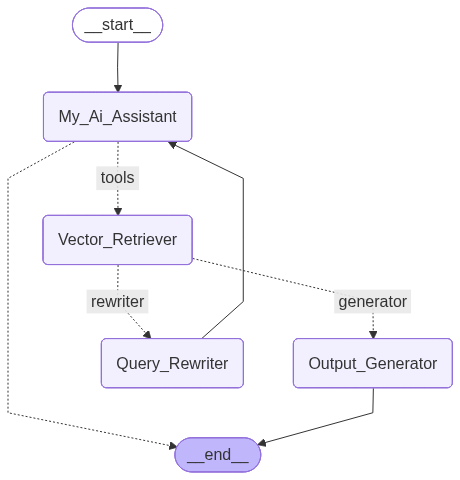

In [18]:
app = workflow.compile()

from IPython.display import Image, display
try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception as e:
    print(e)

In [19]:
result = app.invoke({"messages": [HumanMessage(content="What is an Autonomous Agent?")]})
print(result["messages"][-1].content)

---CALL AGENT---
An autonomous agent is a system or entity that can operate independently, making decisions and taking actions without direct human intervention. It has the ability to perceive its environment, reason about the current state, and adjust its behavior accordingly to achieve its goals. Autonomous agents can be found in various fields, including robotics, artificial intelligence, economics, and biology. They can be simple or complex, ranging from autonomous vehicles to sophisticated AI systems. The key characteristic of an autonomous agent is its ability to self-govern and adapt to changing circumstances, allowing it to interact with its environment in a flexible and dynamic way.


In [20]:
result = app.invoke({"messages": [HumanMessage(content="What is prompt engineering in terms of agents and LangChain?")]})
print(result["messages"][-1].content)

---CALL AGENT---
---DECISION: DOCS RELEVANT---
---GENERATE---
Response: Prompt engineering refers to the process of designing and optimizing text prompts to elicit specific responses from language models or agents. In the context of LangChain, prompt engineering involves crafting prompts that allow agents to effectively interact with language models and generate desired outputs. I don't have more specific information on how it is applied in LangChain.
Prompt engineering refers to the process of designing and optimizing text prompts to elicit specific responses from language models or agents. In the context of LangChain, prompt engineering involves crafting prompts that allow agents to effectively interact with language models and generate desired outputs. I don't have more specific information on how it is applied in LangChain.


In [21]:
result = app.invoke({"messages": [HumanMessage(content="What is the capital of India?")]})
print(result["messages"][-1].content)

---CALL AGENT---
The capital of India is New Delhi.
